# Predoc assessment pipeline

End-to-end tract-level ACS (2019 5-year) construction, merge with PLACES (2021), neighborhood disadvantage index, and OLS models. Raw inputs are read only from `raw_data/`; outputs go to `processed_data/` and `output/`.

**Note:** ACS release year and PLACES release year differ; results are descriptive/ecological OLS without spatial adjustment.


## Setup

Imports, relative paths, and creation of output directories. The notebook assumes seven ACS subfolders under `raw_data/` with the exact Census download names, plus one PLACES tract CSV (`PLACES*.csv`).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats  # available for optional diagnostics
import statsmodels.formula.api as smf

# Relative roots (run notebook from project root)
RAW = Path("raw_data")
PROC = Path("processed_data")
OUT = Path("output")
PROC.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# ACS folder names 
ACS_FOLDER_NAMES = [
    "B08201 HOUSEHOLD SIZE BY VEHICLES AVAILABLE",
    "B11003FAMILY TYPE BY PRESENCE AND AGE OF OWN CHILDREN UNDER 18 YEARS",
    "B25003-Tenure",
    "B25014TENURE BY OCCUPANTS PER ROOM",
    "S1501-Educational Attainment",
    "S1701-Poverty",
    "S2301EMPLOYMENT",
]

for name in ACS_FOLDER_NAMES:
    p = RAW / name
    if not p.is_dir():
        raise FileNotFoundError(f"Missing ACS folder: {p.resolve()}")

places_glob = sorted(RAW.glob("PLACES*.csv"))
if len(places_glob) != 1:
    raise FileNotFoundError(
        f"Expected exactly one PLACES*.csv under {RAW}, found {len(places_glob)}"
    )
PLACES_PATH = places_glob[0]
print("RAW:", RAW.resolve())
print("PLACES:", PLACES_PATH.name)


RAW: /Users/sanchitsingh/Desktop/Cursor_Projects/ZCAFE/raw_data
PLACES: PLACES__Census_Tract_Data_(GIS_Friendly_Format),_2021_release_20260405.csv


## Load Raw Data

Locate each `*Data.csv` and `*Column-Metadata.csv` inside the ACS folders, locate the PLACES file, and load into DataFrames. Census ACS detail/subject CSVs ship a duplicate human-readable header row (row 2); we skip it. Tract identifiers are loaded as strings.


In [2]:
def find_unique_csv(folder: Path, pattern: str) -> Path:
    matches = sorted(folder.glob(pattern))
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected one {pattern} in {folder}, got {len(matches)}")
    return matches[0]


def load_acs_data_csv(path: Path) -> pd.DataFrame:
    # Row 0: machine headers; row 1: label row ("Geography", ...); row 2+: data
    return pd.read_csv(path, header=0, skiprows=[1], dtype={"GEO_ID": str}, low_memory=False)


def load_column_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path, dtype=str)
    meta.columns = [c.strip().strip('"') for c in meta.columns]
    if "Column Name" not in meta.columns or "Label" not in meta.columns:
        raise ValueError(f"Unexpected metadata columns in {path}: {meta.columns.tolist()}")
    meta["Column Name"] = meta["Column Name"].str.strip().str.strip('"')
    meta["Label"] = meta["Label"].str.strip().str.strip('"')
    return meta


acs_paths = {}
for folder_name in ACS_FOLDER_NAMES:
    d = RAW / folder_name
    data_p = find_unique_csv(d, "*Data.csv")
    meta_p = find_unique_csv(d, "*Column-Metadata.csv")
    acs_paths[folder_name] = {"data": data_p, "meta": meta_p}

raw_acs = {k: load_acs_data_csv(v["data"]) for k, v in acs_paths.items()}
meta_acs = {k: load_column_metadata(v["meta"]) for k, v in acs_paths.items()}

places_raw = pd.read_csv(PLACES_PATH, dtype={"TractFIPS": str}, low_memory=False)

print("Loaded ACS tables:", list(raw_acs.keys()))
print("PLACES shape:", places_raw.shape)


Loaded ACS tables: ['B08201 HOUSEHOLD SIZE BY VEHICLES AVAILABLE', 'B11003FAMILY TYPE BY PRESENCE AND AGE OF OWN CHILDREN UNDER 18 YEARS', 'B25003-Tenure', 'B25014TENURE BY OCCUPANTS PER ROOM', 'S1501-Educational Attainment', 'S1701-Poverty', 'S2301EMPLOYMENT']
PLACES shape: (72337, 67)


## Inspect ACS and PLACES Files

Census columns ending in **`E`** are **estimates**; columns ending in **`M`** are **margins of error**. The main analysis uses **estimate columns only** (no MOE).


In [3]:
def brief_inspect(name: str, df: pd.DataFrame, n_cols: int = 12) -> None:
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("first columns:", list(df.columns[:n_cols]))
    print("head(3):")
    display(df.head(3))


for folder_name, df in raw_acs.items():
    brief_inspect(folder_name, df)

brief_inspect("PLACES", places_raw)



=== B08201 HOUSEHOLD SIZE BY VEHICLES AVAILABLE ===
shape: (73056, 8)
first columns: ['GEO_ID', 'NAME', 'B08201_001E', 'B08201_002E', 'B08201_003E', 'B08201_004E', 'B08201_005E', 'B08201_006E']
head(3):


,GEO_ID,NAME,B08201_001E,B08201_002E,B08201_003E,B08201_004E,B08201_005E,B08201_006E
0,1400000US01073001100,"Census Tract 11, Jefferson County, Alabama",1851,277,662,498,211,203
1,1400000US01073001400,"Census Tract 14, Jefferson County, Alabama",816,71,311,295,129,10
2,1400000US01073002000,"Census Tract 20, Jefferson County, Alabama",1419,189,645,503,72,10



=== B11003FAMILY TYPE BY PRESENCE AND AGE OF OWN CHILDREN UNDER 18 YEARS ===
shape: (74001, 43)
first columns: ['GEO_ID', 'NAME', 'B11003_001E', 'B11003_001M', 'B11003_002E', 'B11003_002M', 'B11003_003E', 'B11003_003M', 'B11003_004E', 'B11003_004M', 'B11003_005E', 'B11003_005M']
head(3):


,GEO_ID,NAME,B11003_001E,B11003_001M,B11003_002E,B11003_002M,B11003_003E,B11003_003M,B11003_004E,B11003_004M,...,B11003_016M,B11003_017E,B11003_017M,B11003_018E,B11003_018M,B11003_019E,B11003_019M,B11003_020E,B11003_020M,Unnamed: 42
0,1400000US01001020100,"Census Tract 201, Autauga County, Alabama",567,63,409,65,145,48,19,24,...,32,0,12,17,25,28,26,85,48,NaN
1,1400000US01001020200,"Census Tract 202, Autauga County, Alabama",377,67,235,71,107,52,16,18,...,23,0,12,13,16,14,20,58,28,NaN
2,1400000US01001020300,"Census Tract 203, Autauga County, Alabama",877,119,628,92,301,59,63,49,...,65,0,12,22,35,86,59,83,57,NaN



=== B25003-Tenure ===
shape: (74001, 9)
first columns: ['GEO_ID', 'NAME', 'B25003_001E', 'B25003_001M', 'B25003_002E', 'B25003_002M', 'B25003_003E', 'B25003_003M', 'Unnamed: 8']
head(3):


...

,GEO_ID,NAME,S1701_C01_001E,S1701_C01_001M,S1701_C01_002E,S1701_C01_002M,S1701_C01_003E,S1701_C01_003M,S1701_C01_004E,S1701_C01_004M,...,S1701_C03_057M,S1701_C03_058E,S1701_C03_058M,S1701_C03_059E,S1701_C03_059M,S1701_C03_060E,S1701_C03_060M,S1701_C03_061E,S1701_C03_061M,Unnamed: 368
0,1400000US01001020100,"Census Tract 201, Autauga County, Alabama",1993,225,414,96,115,64,299,88,...,66.3,(X),(X),12.1,12.8,0.0,98.9,14.7,17.5,NaN
1,1400000US01001020200,"Census Tract 202, Autauga County, Alabama",1709,184,378,108,87,44,291,104,...,37.8,(X),(X),0.0,20.5,45.8,31.1,52.4,27.7,NaN
2,1400000US01001020300,"Census Tract 203, Autauga County, Alabama",3507,386,807,208,97,76,710,176,...,11.3,(X),(X),0.0,10.4,56.0,29.4,46.0,21.1,NaN



=== S2301EMPLOYMENT ===
shape: (74001, 283)
first columns: ['GEO_ID', 'NAME', 'S2301_C01_001E', 'S2301_C01_001M', 'S2301_C01_002E', 'S2301_C01_002M', 'S2301_C01_003E', 'S2301_C01_003M', 'S2301_C01_004E', 'S2301_C01_004M', 'S2301_C01_005E', 'S2301_C01_005M']
head(3):


,GEO_ID,NAME,S2301_C01_001E,S2301_C01_001M,S2301_C01_002E,S2301_C01_002M,S2301_C01_003E,S2301_C01_003M,S2301_C01_004E,S2301_C01_004M,...,S2301_C04_031M,S2301_C04_032E,S2301_C04_032M,S2301_C04_033E,S2301_C04_033M,S2301_C04_034E,S2301_C04_034M,S2301_C04_035E,S2301_C04_035M,Unnamed: 282
0,1400000US01001020100,"Census Tract 201, Autauga County, Alabama",1617,177,103,79,191,88,55,40,...,1.3,0.0,51.6,3.4,3.5,0.0,14.1,0.0,11.3,NaN
1,1400000US01001020200,"Census Tract 202, Autauga County, Alabama",1575,154,57,37,115,46,150,54,...,2.6,-,**,2.9,4.0,2.5,5.4,0.0,21.9,NaN
2,1400000US01001020300,"Census Tract 203, Autauga County, Alabama",2799,270,145,82,149,81,304,169,...,3.0,10.2,16.0,2.2,3.3,4.1,6.5,1.5,3.1,NaN



=== PLACES ===
shape: (72337, 67)
first columns: ['StateAbbr', 'StateDesc', 'CountyName', 'CountyFIPS', 'TractFIPS', 'TotalPopulation', 'ACCESS2_CrudePrev', 'ACCESS2_Crude95CI', 'ARTHRITIS_CrudePrev', 'ARTHRITIS_Crude95CI', 'BINGE_CrudePrev', 'BINGE_Crude95CI']
head(3):


,StateAbbr,StateDesc,CountyName,CountyFIPS,TractFIPS,TotalPopulation,ACCESS2_CrudePrev,ACCESS2_Crude95CI,ARTHRITIS_CrudePrev,ARTHRITIS_Crude95CI,...,OBESITY_Crude95CI,PHLTH_CrudePrev,PHLTH_Crude95CI,SLEEP_CrudePrev,SLEEP_Crude95CI,STROKE_CrudePrev,STROKE_Crude95CI,TEETHLOST_CrudePrev,TEETHLOST_Crude95CI,Geolocation
0,AZ,Arizona,Maricopa,4013,04013422643,5789,11.9,"(10.1, 14.0)",17.0,"(16.1, 17.9)",...,"(26.9, 29.7)",9.2,"( 8.2, 10.2)",34.5,"(33.0, 36.3)",1.8,"( 1.6, 2.0)",8.0,"( 5.2, 11.6)",POINT (-111.61853 33.35726769)
1,CA,California,Sacramento,6067,06067007402,6180,15.4,"(13.5, 17.3)",24.6,"(23.8, 25.3)",...,"(29.6, 31.4)",15.1,"(14.2, 16.2)",35.7,"(34.8, 36.7)",3.9,"( 3.6, 4.3)",18.2,"(13.7, 23.5)",POINT (-121.3791473 38.6869681)
2,AL,Alabama,Madison,1089,01089000201,760,25.4,"(21.2, 30.1)",36.0,"(34.6, 37.3)",...,"(46.6, 49.7)",22.5,"(20.4, 24.7)",50.3,"(48.8, 51.3)",7.6,"( 6.8, 8.6)",33.3,"(24.1, 43.8)",POINT (-86.55005486 34.77465775)


## Clean Geography Keys

Build **`GEOID`** as the 11-digit tract FIPS (state + county + tract) from ACS `GEO_ID` (Census uses a `1400000US` + 11-digit pattern). PLACES **`TractFIPS`** is stored as string. We require length 11 after stripping whitespace.


In [4]:
def geo_id_to_geoid(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    # Tract rows: ...US + 11 digits; take last 11 digits if longer
    out = s.str.replace(r"^.*US", "", regex=True)
    out = out.where(~s.str.fullmatch(r"\d{11}"), s)
    return out


def validate_tract_key(series: pd.Series, label: str) -> None:
    s = series.astype(str).str.strip()
    bad = s.isna() | (s == "") | (s == "nan") | (s.str.len() != 11) | (~s.str.fullmatch(r"\d{11}"))
    n_bad = int(bad.sum())
    print(f"{label}: invalid or missing tract keys: {n_bad} / {len(s)}")
    if n_bad:
        print(s[bad].head(10))


for fname, df in raw_acs.items():
    df = df.copy()
    df["GEOID"] = geo_id_to_geoid(df["GEO_ID"])
    raw_acs[fname] = df
    validate_tract_key(df["GEOID"], fname)

# Keep only valid 11-digit tract GEOIDs (drops US/state summaries, etc.)
for fname, df in raw_acs.items():
    ok = df["GEOID"].str.fullmatch(r"\d{11}", na=False)
    n_bad = int((~ok).sum())
    if n_bad:
        print(f"{fname}: dropping {n_bad} rows with non-tract GEOID")
    raw_acs[fname] = df.loc[ok].reset_index(drop=True)

places_raw = places_raw.copy()
places_raw["TractFIPS"] = places_raw["TractFIPS"].astype(str).str.strip()
validate_tract_key(places_raw["TractFIPS"], "PLACES TractFIPS")


B08201 HOUSEHOLD SIZE BY VEHICLES AVAILABLE: invalid or missing tract keys: 0 / 73056
B11003FAMILY TYPE BY PRESENCE AND AGE OF OWN CHILDREN UNDER 18 YEARS: invalid or missing tract keys: 0 / 74001
B25003-Tenure: invalid or missing tract keys: 0 / 74001
B25014TENURE BY OCCUPANTS PER ROOM: invalid or missing tract keys: 0 / 73056
S1501-Educational Attainment: invalid or missing tract keys: 0 / 74001
S1701-Poverty: invalid or missing tract keys: 0 / 74001
S2301EMPLOYMENT: invalid or missing tract keys: 0 / 74001
PLACES TractFIPS: invalid or missing tract keys: 0 / 72337


## Construct ACS Domain Variables

We map human-readable labels from each **Column-Metadata** CSV to estimate (`*E`) columns where helpful, print the chosen names and labels, then compute seven tract percentages. Values like `-`, `(X)`, `**`, and `N` are coerced to numeric NaN.


In [5]:
def find_estimate_columns(
    meta: pd.DataFrame,
    keywords: list,
    *,
    require_all: bool = True,
    label_must_not_contain: list | None = None,
    label_must_startswith: str | None = None,
) -> pd.DataFrame:
    """Return metadata rows for estimate columns whose labels match keywords."""
    label_must_not_contain = label_must_not_contain or []
    est = meta[meta["Column Name"].str.endswith("E", na=False)].copy()
    est = est[~est["Column Name"].str.endswith("M", na=False)]
    if label_must_startswith:
        est = est[est["Label"].astype(str).str.startswith(label_must_startswith)]
    
    def score_label(lbl: str) -> int:
        low = lbl.lower()
        if any(bad.lower() in low for bad in label_must_not_contain):
            return -10_000
        text = " ".join(p.strip().lower() for p in lbl.split("!!"))
        if require_all:
            return sum(1 for k in keywords if k.lower() in text)
        return max((1 if k.lower() in text else 0) for k in keywords)

    est["_score"] = est["Label"].astype(str).map(score_label)
    est = est.sort_values("_score", ascending=False)
    return est


def pick_best_column(meta: pd.DataFrame, keywords: list, **kwargs) -> tuple[str, str]:
    ranked = find_estimate_columns(meta, keywords, **kwargs)
    top = ranked.iloc[0]
    if top["_score"] < len(keywords) and kwargs.get("require_all", True):
        raise ValueError(f"No metadata match for {keywords}; top label: {top['Label']}")
    return top["Column Name"], top["Label"]


def print_pick(var_desc: str, col: str, lbl: str) -> None:
    print(f"\n[{var_desc}]\n  column: {col}\n  label:  {lbl}")


def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")


def safe_pct(num: pd.Series, den: pd.Series) -> pd.Series:
    d = to_num(den)
    n = to_num(num)
    out = n / d.replace(0, np.nan) * 100.0
    return out


# --- S1701: poverty_pct (direct percent below poverty, tract total) ---
m170 = meta_acs["S1701-Poverty"]
sub_pov = m170[
    m170["Column Name"].str.endswith("E")
    & m170["Label"].str.contains("Percent below poverty level", case=False, na=False)
    & m170["Label"].str.contains("Population for whom poverty status is determined", case=False, na=False)
    & ~m170["Label"].str.contains(
        "AGE!!|SEX!!|RACE!!|EDUCATIONAL|EMPLOYMENT|WORK EXPERIENCE|UNRELATED|POVERTY RATIOS|50 percent of|125 percent|150 percent|185 percent|200 percent|300 percent|400 percent|500 percent",
        case=False,
        regex=True,
    )
]
if sub_pov.empty:
    raise ValueError("Could not isolate tract-level percent below poverty in S1701 metadata")
c_pov = sub_pov.iloc[0]["Column Name"]
l_pov = sub_pov.iloc[0]["Label"]
print_pick("poverty_pct (direct ACS percent)", c_pov, l_pov)
df170 = raw_acs["S1701-Poverty"][["GEOID"]].copy()
df170["poverty_pct"] = to_num(raw_acs["S1701-Poverty"][c_pov])

# --- S1501: low_edu_pct (counts: Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT...) ---
m150 = meta_acs["S1501-Educational Attainment"]
pfx = "Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT"
c_lo9, l_lo9 = pick_best_column(
    m150,
    ["less than 9th grade", "25 years and over"],
    label_must_startswith=pfx,
    label_must_not_contain=["poverty", "median", "earnings", "race", "hispanic", "percent"],
)
c_912, l_912 = pick_best_column(
    m150,
    ["9th to 12th grade", "no diploma", "25 years and over"],
    label_must_startswith=pfx,
    label_must_not_contain=["poverty", "median", "earnings", "race", "hispanic", "percent"],
)
ranked_den = find_estimate_columns(
    m150,
    ["population 25 years and over"],
    require_all=True,
    label_must_startswith=pfx,
    label_must_not_contain=[
        "less than",
        "high school",
        "some college",
        "associate",
        "bachelor",
        "graduate",
        "poverty",
        "median",
        "race",
        "hispanic",
        "percent",
        "18 to 24",
        "25 to 34",
        "35 to 44",
        "45 to 64",
        "65 years",
    ],
)
c_den_edu = ranked_den.iloc[0]["Column Name"]
l_den_edu = ranked_den.iloc[0]["Label"]
print_pick("low_edu_pct numerator (less than 9th)", c_lo9, l_lo9)
print_pick("low_edu_pct numerator (9th-12th no diploma)", c_912, l_912)
print_pick("low_edu_pct denominator (pop 25+)", c_den_edu, l_den_edu)
df150 = raw_acs["S1501-Educational Attainment"][["GEOID"]].copy()
num_edu = to_num(raw_acs["S1501-Educational Attainment"][c_lo9]) + to_num(
    raw_acs["S1501-Educational Attainment"][c_912]
)
df150["low_edu_pct"] = safe_pct(num_edu, raw_acs["S1501-Educational Attainment"][c_den_edu])

# --- B11003: single_parent_pct ---
# Totals for male/female householder with own children under 18 (all child ages).
# Do not use keyword ranking here: it can pick a narrower age sub-row (e.g. B11003_019E = 6–17 only).
def b11003_own_children_under18_total(meta: pd.DataFrame, *, female: bool) -> tuple[str, str]:
    suf = (
        "!!Female householder, no spouse present:!!With own children of the householder under 18 years:"
        if female
        else "!!Male householder, no spouse present:!!With own children of the householder under 18 years:"
    )
    sub = meta[
        meta["Column Name"].str.endswith("E", na=False) & meta["Label"].str.endswith(suf, na=False)
    ]
    if len(sub) != 1:
        who = "female" if female else "male"
        raise ValueError(f"B11003: expected one {who} under-18-with-own-children total (suffix …{suf[-40:]}), got {len(sub)}")
    row = sub.iloc[0]
    return row["Column Name"], row["Label"]


m110 = meta_acs["B11003FAMILY TYPE BY PRESENCE AND AGE OF OWN CHILDREN UNDER 18 YEARS"]
c_male, l_male = b11003_own_children_under18_total(m110, female=False)
c_fem, l_fem = b11003_own_children_under18_total(m110, female=True)
tot_row = m110[
    m110["Column Name"].str.endswith("E")
    & m110["Label"].str.fullmatch("Estimate!!Total:", case=False)
]
if tot_row.empty:
    raise ValueError("B11003 total families row not found")
c_fam_tot = tot_row.iloc[0]["Column Name"]
l_fam_tot = tot_row.iloc[0]["Label"]
print_pick("single_parent_pct male with children <18", c_male, l_male)
print_pick("single_parent_pct female with children <18", c_fem, l_fem)
print_pick("single_parent_pct denominator total families", c_fam_tot, l_fam_tot)
df110 = raw_acs["B11003FAMILY TYPE BY PRESENCE AND AGE OF OWN CHILDREN UNDER 18 YEARS"][["GEOID"]].copy()
b = raw_acs["B11003FAMILY TYPE BY PRESENCE AND AGE OF OWN CHILDREN UNDER 18 YEARS"]
df110["single_parent_pct"] = safe_pct(
    to_num(b[c_male]) + to_num(b[c_fem]), b[c_fam_tot]
)

# --- B25003: renter_pct ---
m2503 = meta_acs["B25003-Tenure"]
c_ren, l_ren = pick_best_column(m2503, ["renter occupied"], require_all=True)
tot2503 = m2503[
    m2503["Column Name"].str.endswith("E")
    & m2503["Label"].str.fullmatch("Estimate!!Total:", case=False)
]
c_occ = tot2503.iloc[0]["Column Name"]
l_occ = tot2503.iloc[0]["Label"]
print_pick("renter_pct numerator", c_ren, l_ren)
print_pick("renter_pct denominator", c_occ, l_occ)
b3 = raw_acs["B25003-Tenure"]
df2503 = b3[["GEOID"]].copy()
df2503["renter_pct"] = safe_pct(b3[c_ren], b3[c_occ])

# --- B25014: overcrowded_pct (1.01+ per room, owner + renter) ---
m2514 = meta_acs["B25014TENURE BY OCCUPANTS PER ROOM"]


def pick2514(kws, not_contain=None):
    return pick_best_column(
        m2514, kws, label_must_not_contain=not_contain if not_contain is not None else []
    )


cols_2514 = {
    "own_101": pick2514(["owner occupied", "1.01 to 1.50"]),
    "own_151": pick2514(["owner occupied", "1.51 to 2.00"]),
    "own_201": pick2514(["owner occupied", "2.01 or more"]),
    "rent_101": pick2514(["renter occupied", "1.01 to 1.50"]),
    "rent_151": pick2514(["renter occupied", "1.51 to 2.00"]),
    "rent_201": pick2514(["renter occupied", "2.01 or more"]),
    "total_occ": pick2514(["total"], ["owner", "renter"]),
}
for k, (c, l) in cols_2514.items():
    print_pick(f"overcrowded_pct component {k}", c, l)
b14 = raw_acs["B25014TENURE BY OCCUPANTS PER ROOM"]
_oc_cols = [cols_2514[k][0] for k in ["own_101", "own_151", "own_201", "rent_101", "rent_151", "rent_201"]]
num_oc = sum(to_num(b14[c]) for c in _oc_cols)
df2514 = b14[["GEOID"]].copy()
df2514["overcrowded_pct"] = safe_pct(num_oc, b14[cols_2514["total_occ"][0]])

# --- B08201: no_vehicle_pct (total no vehicle / total households) ---
m082 = meta_acs["B08201 HOUSEHOLD SIZE BY VEHICLES AVAILABLE"]
c_noveh, l_noveh = pick_best_column(
    m082,
    ["no vehicle available"],
    label_must_not_contain=["1-person", "2-person", "3-person", "4-person", "5-person"],
)
tot082 = m082[
    m082["Column Name"].str.endswith("E")
    & (m082["Label"].str.lower() == "estimate!!total:")
]
c_hhtot = tot082.iloc[0]["Column Name"]
l_hhtot = tot082.iloc[0]["Label"]
print_pick("no_vehicle_pct numerator", c_noveh, l_noveh)
print_pick("no_vehicle_pct denominator", c_hhtot, l_hhtot)
b82 = raw_acs["B08201 HOUSEHOLD SIZE BY VEHICLES AVAILABLE"]
df082 = b82[["GEOID"]].copy()
df082["no_vehicle_pct"] = safe_pct(b82[c_noveh], b82[c_hhtot])

# --- S2301: nonemployed_u65_pct ---
m230 = meta_acs["S2301EMPLOYMENT"]
c_epr, l_epr = pick_best_column(
    m230,
    ["employment/population ratio", "20 to 64 years"],
    label_must_not_contain=[
        "poverty",
        "disability",
        "educational attainment",
        "sex!!",
        "female!!",
        "male!!",
        "with own children",
    ],
)
print_pick("nonemployed_u65_pct from employment-pop ratio 20-64", c_epr, l_epr)
df230 = raw_acs["S2301EMPLOYMENT"][["GEOID"]].copy()
epr = to_num(raw_acs["S2301EMPLOYMENT"][c_epr])
# Ratio may be 0-100 or 0-1
if epr.dropna().max() is not None and epr.dropna().max() <= 1.5:
    epr = epr * 100.0
df230["nonemployed_u65_pct"] = 100.0 - epr

acs_parts = {
    "poverty": df170,
    "low_edu": df150,
    "single_parent": df110,
    "renter": df2503,
    "overcrowded": df2514,
    "no_vehicle": df082,
    "nonemployed": df230,
}



[poverty_pct (direct ACS percent)]
  column: S1701_C03_001E
  label:  Estimate!!Percent below poverty level!!Population for whom poverty status is determined

[low_edu_pct numerator (less than 9th)]
  column: S1501_C01_007E
  label:  Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 years and over!!Less than 9th grade

[low_edu_pct numerator (9th-12th no diploma)]
  column: S1501_C01_008E
  label:  Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 years and over!!9th to 12th grade, no diploma

[low_edu_pct denominator (pop 25+)]
  column: S1501_C01_006E
  label:  Estimate!!Total!!AGE BY EDUCATIONAL ATTAINMENT!!Population 25 years and over

[single_parent_pct male with children <18]
  column: B11003_010E
  label:  Estimate!!Total:!!Other family:!!Male householder, no spouse present:!!With own children of the householder under 18 years:

[single_parent_pct female with children <18]
  column: B11003_016E
  label:  Estimate!!Total:!!Other family:!!Female householde

## Merge ACS Tables

Combine the seven domain tables on **`GEOID`**. Before merging, check for duplicate tract keys within each table. Print row counts before the merge chain and after the final merge.


In [6]:
for name, d in acs_parts.items():
    dup = d["GEOID"].duplicated().sum()
    if dup:
        raise ValueError(f"Duplicate GEOID in {name}: {dup}")

counts_log = []
current = None
for name, d in acs_parts.items():
    counts_log.append((name, len(d)))
    if current is None:
        current = d.copy()
    else:
        before = len(current)
        current = current.merge(d, on="GEOID", how="outer", validate="one_to_one")
        after = len(current)
        print(f"merge {name}: rows {before} -> {after}")

acs_master = current[
    [
        "GEOID",
        "poverty_pct",
        "low_edu_pct",
        "single_parent_pct",
        "renter_pct",
        "overcrowded_pct",
        "no_vehicle_pct",
        "nonemployed_u65_pct",
    ]
].copy()

print("Per-table row counts:", counts_log)
print("acs_master rows:", len(acs_master))
acs_master.to_csv(PROC / "acs_master.csv", index=False)
print("Wrote", PROC / "acs_master.csv")


merge low_edu: rows 74001 -> 74001
merge single_parent: rows 74001 -> 74001
merge renter: rows 74001 -> 74001
merge overcrowded: rows 74001 -> 74001
merge no_vehicle: rows 74001 -> 74001
merge nonemployed: rows 74001 -> 74001
Per-table row counts: [('poverty', 74001), ('low_edu', 74001), ('single_parent', 74001), ('renter', 74001), ('overcrowded', 73056), ('no_vehicle', 73056), ('nonemployed', 74001)]
acs_master rows: 74001
Wrote processed_data/acs_master.csv


## Merge with PLACES

Keep **`TractFIPS`**, mental health crude prevalence, and obesity crude prevalence. Merge ACS to PLACES on **`GEOID` == `TractFIPS`**. Report how many PLACES tracts matched vs unmatched on the ACS side.


In [7]:
places_sub = places_raw[["TractFIPS", "MHLTH_CrudePrev", "OBESITY_CrudePrev"]].copy()
places_sub["MHLTH_CrudePrev"] = pd.to_numeric(places_sub["MHLTH_CrudePrev"], errors="coerce")
places_sub["OBESITY_CrudePrev"] = pd.to_numeric(places_sub["OBESITY_CrudePrev"], errors="coerce")

merged = acs_master.merge(
    places_sub,
    left_on="GEOID",
    right_on="TractFIPS",
    how="left",
    indicator=True,
)
n_matched = int((merged["_merge"] == "both").sum())
n_acs_only = int((merged["_merge"] == "left_only").sum())
n_places = len(places_sub)
print("ACS tracts:", len(acs_master))
print("PLACES tracts:", n_places)
print("Matched (ACS row with PLACES):", n_matched)
print("ACS rows without PLACES match:", n_acs_only)

analysis_file = merged.drop(columns=["_merge"])
analysis_file.to_csv(PROC / "analysis_file.csv", index=False)
print("Wrote", PROC / "analysis_file.csv")


ACS tracts: 74001
PLACES tracts: 72337
Matched (ACS row with PLACES): 72335
ACS rows without PLACES match: 1666
Wrote processed_data/analysis_file.csv


## Missingness and Cleaning Decisions

Summarize missing values for all variables used in the main analysis, then **drop** any tract with a missing value in any of the seven ACS percentages or the two PLACES outcomes. Save a log of dropped tracts with indicators of which fields were missing.


In [8]:
analysis_cols = [
    "GEOID",
    "TractFIPS",
    "poverty_pct",
    "low_edu_pct",
    "single_parent_pct",
    "renter_pct",
    "overcrowded_pct",
    "no_vehicle_pct",
    "nonemployed_u65_pct",
    "MHLTH_CrudePrev",
    "OBESITY_CrudePrev",
]
work = analysis_file[analysis_cols].copy()

miss_rate = work.isna().mean()
print("Missingness rate (pre-drop):")
display(miss_rate.to_frame("missing_rate"))

req = [
    "poverty_pct",
    "low_edu_pct",
    "single_parent_pct",
    "renter_pct",
    "overcrowded_pct",
    "no_vehicle_pct",
    "nonemployed_u65_pct",
    "MHLTH_CrudePrev",
    "OBESITY_CrudePrev",
]
miss_mask = work[req].isna().any(axis=1)
n_drop = int(miss_mask.sum())
print("Tracts dropped (any missing in required vars):", n_drop)

dropped = work.loc[miss_mask].copy()
for c in req:
    dropped[f"miss_{c}"] = dropped[c].isna()
dropped.to_csv(OUT / "dropped_tracts_log.csv", index=False)
print("Wrote", OUT / "dropped_tracts_log.csv")

analysis_complete = work.loc[~miss_mask].copy()
print("Analysis rows after drop:", len(analysis_complete))


Missingness rate (pre-drop):


,missing_rate
GEOID,0.000000
TractFIPS,0.022513
poverty_pct,0.011513
low_edu_pct,0.009743
single_parent_pct,0.012703
renter_pct,0.012000
overcrowded_pct,0.023973
no_vehicle_pct,0.023973
nonemployed_u65_pct,0.009621
MHLTH_CrudePrev,0.049526


Tracts dropped (any missing in required vars): 3868
Wrote output/dropped_tracts_log.csv
Analysis rows after drop: 70133


## Construct Neighborhood Disadvantage Index

Z-standardize the seven ACS percentages on the **complete-case analysis sample** using population `ddof=0`. Each input is already coded so that **higher = more disadvantage** (including `nonemployed_u65_pct`). The index is the **mean of the seven z-scores**.


In [9]:
acs_for_index = [
    "poverty_pct",
    "low_edu_pct",
    "single_parent_pct",
    "renter_pct",
    "overcrowded_pct",
    "no_vehicle_pct",
    "nonemployed_u65_pct",
]

z_parts = {}
for c in acs_for_index:
    v = analysis_complete[c].astype(float)
    mu = v.mean()
    sd = v.std(ddof=0)
    if sd == 0 or (isinstance(sd, float) and np.isnan(sd)):
        z = pd.Series(np.nan, index=v.index)
    else:
        z = (v - mu) / sd
    z_parts[f"z_{c}"] = z
    print(f"{c}: higher values indicate more disadvantage (conceptual check documented in markdown).")

z_df = pd.DataFrame(z_parts, index=analysis_complete.index)
analysis_idx = analysis_complete.copy()
analysis_idx[z_df.columns] = z_df
analysis_idx["disadvantage_index"] = z_df.mean(axis=1)

analysis_idx.to_csv(PROC / "analysis_file_with_index.csv", index=False)
print("Wrote", PROC / "analysis_file_with_index.csv")


poverty_pct: higher values indicate more disadvantage (conceptual check documented in markdown).
low_edu_pct: higher values indicate more disadvantage (conceptual check documented in markdown).
single_parent_pct: higher values indicate more disadvantage (conceptual check documented in markdown).
renter_pct: higher values indicate more disadvantage (conceptual check documented in markdown).
overcrowded_pct: higher values indicate more disadvantage (conceptual check documented in markdown).
no_vehicle_pct: higher values indicate more disadvantage (conceptual check documented in markdown).
nonemployed_u65_pct: higher values indicate more disadvantage (conceptual check documented in markdown).
Wrote processed_data/analysis_file_with_index.csv


## Descriptive Statistics

Summary statistics for the seven ACS domain variables and **`disadvantage_index`**, plus a histogram of the index saved under `output/`.


Wrote output/index_descriptives.csv


,count,mean,std,min,25%,50%,75%,max
poverty_pct,70133.0,1.470982e+01,11.438358,0.00000,6.300000,11.600000,19.900000,100.000000
low_edu_pct,70133.0,1.268746e+01,10.303474,0.00000,5.286432,9.850276,17.140280,81.656627
single_parent_pct,70133.0,1.449538e+01,10.412160,0.00000,7.124011,11.989101,19.306184,100.000000
renter_pct,70133.0,3.654064e+01,22.776453,0.00000,18.513690,31.548536,51.000000,100.000000
overcrowded_pct,70133.0,3.570869e+00,5.135779,0.00000,0.588865,1.881225,4.398448,100.000000
no_vehicle_pct,70133.0,9.186793e+00,12.102647,0.00000,2.375297,5.188679,10.722348,100.000000
nonemployed_u65_pct,70133.0,2.754231e+01,10.658592,0.00000,20.300000,25.500000,32.600000,100.000000
disadvantage_index,70133.0,-2.431527e-17,0.707235,-1.36462,-0.526841,-0.172243,0.368709,4.098063


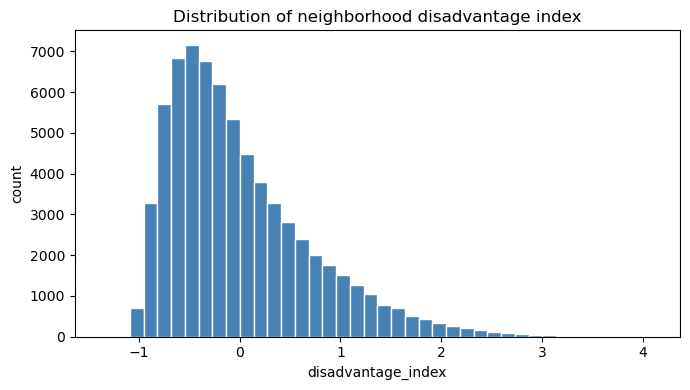

Wrote output/disadvantage_index_hist.png


In [10]:
desc_cols = acs_for_index + ["disadvantage_index"]
desc = analysis_idx[desc_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc.to_csv(OUT / "index_descriptives.csv")
print("Wrote", OUT / "index_descriptives.csv")
display(desc)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(analysis_idx["disadvantage_index"].dropna(), bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("disadvantage_index")
ax.set_ylabel("count")
ax.set_title("Distribution of neighborhood disadvantage index")
fig.tight_layout()
fig.savefig(OUT / "disadvantage_index_hist.png", dpi=150)
plt.show()
print("Wrote", OUT / "disadvantage_index_hist.png")


## Main Regressions

Ordinary least squares at the tract level: PLACES crude prevalence regressed on **`disadvantage_index`** (separate models for mental health and obesity).


In [11]:
def regression_table_csv(result, path: Path) -> None:
    tbl = pd.DataFrame(
        {
            "coef": result.params,
            "std_err": result.bse,
            "pvalue": result.pvalues,
        }
    )
    tbl.loc["nobs", "coef"] = float(result.nobs)
    tbl.loc["rsquared", "coef"] = float(result.rsquared)
    tbl.to_csv(path)
    print("Wrote", path)


fit_mhlth = smf.ols("MHLTH_CrudePrev ~ disadvantage_index", data=analysis_idx).fit()
fit_obesity = smf.ols("OBESITY_CrudePrev ~ disadvantage_index", data=analysis_idx).fit()
print(fit_mhlth.summary())
print(fit_obesity.summary())

regression_table_csv(fit_mhlth, OUT / "regression_mhlth_main.csv")
regression_table_csv(fit_obesity, OUT / "regression_obesity_main.csv")


                            OLS Regression Results                            
Dep. Variable:        MHLTH_CrudePrev   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                 6.972e+04
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:25:26   Log-Likelihood:            -1.6412e+05
No. Observations:               70133   AIC:                         3.282e+05
Df Residuals:                   70131   BIC:                         3.283e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             15.1946      0

## Robustness check: leave-one-domain-out index

This tests whether the main associations are driven disproportionately by any single component of the index.


In [12]:
# Leave-one-domain-out indices: same z_* as main index; average the remaining six z-scores per row.
DROP_COL = {
    "poverty_pct": "idx_drop_poverty",
    "low_edu_pct": "idx_drop_low_edu",
    "single_parent_pct": "idx_drop_single_parent",
    "renter_pct": "idx_drop_renter",
    "overcrowded_pct": "idx_drop_overcrowded",
    "no_vehicle_pct": "idx_drop_no_vehicle",
    "nonemployed_u65_pct": "idx_drop_nonemployed",
}

z_cols_all = [f"z_{c}" for c in acs_for_index]
for c in acs_for_index:
    zc = f"z_{c}"
    keep = [zc2 for zc2 in z_cols_all if zc2 != zc]
    analysis_idx[DROP_COL[c]] = analysis_idx[keep].mean(axis=1)


def summarize_predictor(result, pred: str) -> dict:
    return {
        "coef": float(result.params[pred]),
        "se": float(result.bse[pred]),
        "pvalue": float(result.pvalues[pred]),
        "r2": float(result.rsquared),
        "n": int(result.nobs),
    }


OUTCOMES = ("MHLTH_CrudePrev", "OBESITY_CrudePrev")
loo_rows = []
for omitted in acs_for_index:
    pred = DROP_COL[omitted]
    for outcome in OUTCOMES:
        fit = smf.ols(f"{outcome} ~ {pred}", data=analysis_idx).fit()
        s = summarize_predictor(fit, pred)
        loo_rows.append(
            {
                "outcome": outcome,
                "omitted_domain": omitted,
                **s,
            }
        )

loo_long_df = pd.DataFrame(loo_rows)
loo_long_df.to_csv(OUT / "robustness_leave_one_out.csv", index=False)
print("Wrote", OUT / "robustness_leave_one_out.csv")

# Wide: one row per omitted ACS domain; coef / se / pvalue / r2 / n per outcome (columns prefixed by outcome name)
wide_parts = []
for outcome in OUTCOMES:
    subw = loo_long_df[loo_long_df["outcome"] == outcome].drop(columns=["outcome"])
    subw = subw.rename(
        columns={k: f"{outcome}_{k}" for k in ("coef", "se", "pvalue", "r2", "n")}
    )
    wide_parts.append(subw.set_index("omitted_domain"))
loo_wide = pd.concat(wide_parts, axis=1).reset_index()
loo_wide.to_csv(OUT / "robustness_leave_one_out_wide.csv", index=False)
print("Wrote", OUT / "robustness_leave_one_out_wide.csv")

# Printed interpretation (composition robustness)
ALPHA = 0.05
REL_MATERIAL = 0.15  # flag if |beta_loo - beta_main| / |beta_main| > this
main_coef_by_outcome = {
    "MHLTH_CrudePrev": float(fit_mhlth.params["disadvantage_index"]),
    "OBESITY_CrudePrev": float(fit_obesity.params["disadvantage_index"]),
}
for outcome in OUTCOMES:
    sub = loo_long_df[loo_long_df["outcome"] == outcome].copy()
    coefs = sub["coef"].astype(float)
    beta_main = main_coef_by_outcome[outcome]
    all_pos = bool((coefs > 0).all())
    all_sig = bool((sub["pvalue"] < ALPHA).all())
    cmin, cmax = float(coefs.min()), float(coefs.max())
    rng = cmax - cmin
    rel_diff = (coefs - beta_main).abs() / abs(beta_main)
    imax = int(rel_diff.values.argmax()) if len(sub) else 0
    material = sub.iloc[imax]["omitted_domain"] if len(sub) else None
    material_rel = float(rel_diff.max()) if len(sub) else float("nan")
    lost_sig = sub.loc[sub["pvalue"] >= ALPHA, "omitted_domain"].tolist()
    non_pos = sub.loc[sub["coef"] <= 0, "omitted_domain"].tolist()
    print(f"\n--- Leave-one-out: {outcome} ---")
    print(f"Main index coefficient (reference): {beta_main:.6f}")
    print(f"All LOO coefficients > 0: {all_pos}" + (f"; non-positive when omitting: {non_pos}" if not all_pos else ""))
    print(f"All LOO p < {ALPHA}: {all_sig}" + (f"; not significant when omitting: {lost_sig}" if not all_sig else ""))
    print(f"Range of LOO coefficients (min to max): {cmin:.6f} to {cmax:.6f} (span {rng:.6f})")
    print(
        "Material change vs main (rule: relative gap > "
        f"{REL_MATERIAL:.0%} or loss of significance): "
        f"max relative gap {material_rel:.3f} (worst at omitted_domain={material!r}); "
        f"non-significant models: {lost_sig or 'none'}"
    )


Wrote output/robustness_leave_one_out.csv
Wrote output/robustness_leave_one_out_wide.csv

--- Leave-one-out: MHLTH_CrudePrev ---
Main index coefficient (reference): 3.541854
All LOO coefficients > 0: True
All LOO p < 0.05: True
Range of LOO coefficients (min to max): 3.154320 to 3.636379 (span 0.482059)
Material change vs main (rule: relative gap > 15% or loss of significance): max relative gap 0.109 (worst at omitted_domain='nonemployed_u65_pct'); non-significant models: none

--- Leave-one-out: OBESITY_CrudePrev ---
Main index coefficient (reference): 4.491205
All LOO coefficients > 0: True
All LOO p < 0.05: True
Range of LOO coefficients (min to max): 3.859901 to 4.981528 (span 1.121627)
Material change vs main (rule: relative gap > 15% or loss of significance): max relative gap 0.141 (worst at omitted_domain='nonemployed_u65_pct'); non-significant models: none


In [13]:
# Combined tables for reporting: main index models and compact comparison vs leave-one-out range


def _fit_row(model_label: str, outcome: str, pred: str, fit) -> dict:
    return {
        "model": model_label,
        "outcome": outcome,
        "predictor": pred,
        "coef": float(fit.params[pred]),
        "se": float(fit.bse[pred]),
        "pvalue": float(fit.pvalues[pred]),
        "r2": float(fit.rsquared),
        "n": int(fit.nobs),
    }


main_combined = pd.DataFrame(
    [
        _fit_row("main_disadvantage_index", "MHLTH_CrudePrev", "disadvantage_index", fit_mhlth),
        _fit_row("main_disadvantage_index", "OBESITY_CrudePrev", "disadvantage_index", fit_obesity),
    ]
)
main_combined.to_csv(OUT / "regression_main_models.csv", index=False)
print("Wrote", OUT / "regression_main_models.csv")

# Main index vs best/worst leave-one-out coefficient for each outcome
comp = []
for outcome in OUTCOMES:
    fit_main = fit_mhlth if outcome == "MHLTH_CrudePrev" else fit_obesity
    beta_main = float(fit_main.params["disadvantage_index"])
    sub = loo_long_df[loo_long_df["outcome"] == outcome].reset_index(drop=True)
    loo_coef = sub["coef"].astype(float)
    imin = int(loo_coef.values.argmin())
    imax = int(loo_coef.values.argmax())
    rel_gap = (loo_coef - beta_main).abs() / abs(beta_main)
    any_nonsig = bool((sub["pvalue"] >= 0.05).any())
    any_rel_gap = bool((rel_gap > 0.15).any())
    comp.append(
        {
            "outcome": outcome,
            "coef_main_index": beta_main,
            "loo_coef_min": float(loo_coef.iloc[imin]),
            "loo_coef_max": float(loo_coef.iloc[imax]),
            "loo_omitted_at_min_coef": sub.iloc[imin]["omitted_domain"],
            "loo_omitted_at_max_coef": sub.iloc[imax]["omitted_domain"],
            "loo_span": float(loo_coef.max() - loo_coef.min()),
            "loo_all_coef_positive": bool((loo_coef > 0).all()),
            "loo_all_p_lt_0.05": bool((sub["pvalue"] < 0.05).all()),
            "any_loo_nonsignificant": any_nonsig,
            "any_loo_rel_gap_gt_15pct_vs_main": any_rel_gap,
        }
    )
comparison_summary_df = pd.DataFrame(comp)
comparison_summary_df.to_csv(OUT / "robustness_comparison_summary.csv", index=False)
print("Wrote", OUT / "robustness_comparison_summary.csv")


Wrote output/regression_main_models.csv
Wrote output/robustness_comparison_summary.csv


## Export Outputs

Confirm that processed analysis tables and regression outputs exist at the expected relative paths (re-writing ensures a full rerun refreshes all artifacts).


In [14]:
acs_master.to_csv(PROC / "acs_master.csv", index=False)
analysis_file.to_csv(PROC / "analysis_file.csv", index=False)
analysis_idx.to_csv(PROC / "analysis_file_with_index.csv", index=False)
desc.to_csv(OUT / "index_descriptives.csv")
regression_table_csv(fit_mhlth, OUT / "regression_mhlth_main.csv")
regression_table_csv(fit_obesity, OUT / "regression_obesity_main.csv")

main_combined.to_csv(OUT / "regression_main_models.csv", index=False)
loo_long_df.to_csv(OUT / "robustness_leave_one_out.csv", index=False)
loo_wide.to_csv(OUT / "robustness_leave_one_out_wide.csv", index=False)
comparison_summary_df.to_csv(OUT / "robustness_comparison_summary.csv", index=False)

for p in [
    PROC / "acs_master.csv",
    PROC / "analysis_file.csv",
    PROC / "analysis_file_with_index.csv",
    OUT / "index_descriptives.csv",
    OUT / "regression_mhlth_main.csv",
    OUT / "regression_obesity_main.csv",
    OUT / "regression_main_models.csv",
    OUT / "robustness_leave_one_out.csv",
    OUT / "robustness_leave_one_out_wide.csv",
    OUT / "robustness_comparison_summary.csv",
    OUT / "dropped_tracts_log.csv",
    OUT / "disadvantage_index_hist.png",
]:
    print(p.resolve().exists(), p)


Wrote output/regression_mhlth_main.csv
Wrote output/regression_obesity_main.csv
True processed_data/acs_master.csv
True processed_data/analysis_file.csv
True processed_data/analysis_file_with_index.csv
True output/index_descriptives.csv
True output/regression_mhlth_main.csv
True output/regression_obesity_main.csv
True output/regression_main_models.csv
True output/robustness_leave_one_out.csv
True output/robustness_leave_one_out_wide.csv
True output/robustness_comparison_summary.csv
True output/dropped_tracts_log.csv
True output/disadvantage_index_hist.png
